# Static TRACER: Banking77 Intent Routing

This notebook walks you through building a full TRACER routing policy **from scratch** on the [Banking77](https://huggingface.co/datasets/PolyAI/banking77) dataset - 77 fine-grained bank customer support intents.

## The scenario

A retail bank's support chatbot routes **every** incoming customer query to an LLM for intent classification. TRACER learns *when* a local surrogate model can handle the query safely (because it would agree with the LLM with high probability) and *when* to defer back to the LLM. The result is a **parity-gated router**: it only accepts a prediction when confident it matches what the teacher LLM would say.

## What you'll build

```
Customer query
      │
      ▼
  [Embedder]  ← BGE-M3 (1024-dim)
      │
      ▼
  [TRACER Router]
      ├── accept_score ≥ threshold  →  Local surrogate label  (cheap, fast)
      └── accept_score < threshold  →  Defer to teacher LLM   (expensive, reliable)
```

## Notebook structure

| # | Section | What happens |
|---|---|---|
| 1 | **The Dataset** | Load Banking77 from HuggingFace, explore 77 intents |
| 2 | **LLM Traces** | Format data as JSONL teacher traces |
| 3 | **Embeddings** | Load precomputed BGE-M3 embeddings from HuggingFace |
| 4 | **Fit TRACER** | Three candidate families; best selected by coverage |
| 5 | **Artifacts** | Manifest, config, coverage-TA frontier |
| 6 | **XAI Report** | Four explainability lenses grounded in published literature |
| 7 | **Test Evaluation** | Honest hold-out metrics: coverage, F1, teacher agreement |
| 8 | **Production Router** | `tracer.load_router()`, single and batch prediction |
| 9 | **Cost Analysis** | LLM spend saved by routing locally |

> **Static vs Dynamic:** This notebook fits on the full dataset at once. A companion `03-dynamic-tracer.ipynb` simulates traces arriving over time, showing the continual-learning flywheel and temporal deltas.

> **Data:** Precomputed BGE-M3 embeddings are downloaded automatically from [adamrida/tracer-banking77](https://huggingface.co/datasets/adamrida/tracer-banking77). No API keys required.

In [1]:
import sys
from pathlib import Path

# Add tracer/src to sys.path so `import tracer` works without pip install.
_src = (Path('..') / 'src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

print(f'Added to sys.path: {_src}')

# -- Download precomputed data from HuggingFace --
try:
    from huggingface_hub import hf_hub_download
    HF_REPO = "adamrida/tracer-banking77"
    DATA_DIR = Path('data')
    DATA_DIR.mkdir(exist_ok=True)

    _hf_files = {
        "banking77_traces.jsonl": DATA_DIR / "banking77_traces.jsonl",
        "banking77_embeddings.npy": DATA_DIR / "banking77_traces.npy",
        "banking77_test_embeddings.npy": DATA_DIR / "banking77_test_embeddings.npy",
    }
    for hf_name, local_path in _hf_files.items():
        if not local_path.exists():
            dl = hf_hub_download(HF_REPO, hf_name, repo_type="dataset")
            import shutil
            shutil.copy(dl, local_path)
            print(f'  Downloaded {hf_name} -> {local_path}')
        else:
            print(f'  Exists: {local_path}')

    # Copy as train embeddings alias (notebook references this name)
    _train_alias = DATA_DIR / "banking77_train_embeddings.npy"
    if not _train_alias.exists() and (DATA_DIR / "banking77_traces.npy").exists():
        shutil.copy(DATA_DIR / "banking77_traces.npy", _train_alias)
        print(f'  Aliased -> {_train_alias}')

    print('Precomputed data ready.')
except ImportError:
    print('huggingface_hub not installed. Run: pip install huggingface_hub')

Added to sys.path: /Users/adamrida/Library/Mobile Documents/com~apple~CloudDocs/suro-1/tracer/src


In [2]:
import os
import json
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')

import tracer
from tracer.config import FitConfig

DATA_DIR     = Path('data')
ARTIFACT_DIR = Path('.tracer-banking77')
DATA_DIR.mkdir(exist_ok=True)

print(f'tracer {tracer.__version__}')
print(f'data dir:     {DATA_DIR.resolve()}')
print(f'artifact dir: {ARTIFACT_DIR.resolve()}')

tracer 0.1.0
data dir:     /Users/adamrida/Library/Mobile Documents/com~apple~CloudDocs/suro-1/tracer/notebooks/data
artifact dir: /Users/adamrida/Library/Mobile Documents/com~apple~CloudDocs/suro-1/tracer/notebooks/.tracer-banking77


---
## 1. The Dataset - Banking77

Banking77 is a widely-used benchmark for **fine-grained intent classification** in customer banking support:
- **10,003 training** and **3,080 test** customer queries
- **77 intent classes** - card management, transfers, account settings, exchange rates, and more
- **Very short texts** (~15 tokens on average) - cheap to embed and cheap per LLM call

### Why is this hard to route?

Many intents are semantically close: `card_arrival` vs `card_delivery_estimate`, `balance_not_updated_after_bank_transfer` vs `balance_not_updated_after_cheque_or_cash_deposit`. A global surrogate will be confident on the easy intents but uncertain at the boundaries. TRACER learns to handle the confident slice locally and defer the rest.

In [3]:
from datasets import load_dataset

ds          = load_dataset('PolyAI/banking77', trust_remote_code=True)
label_names = ds['train'].features['label'].names

train_df = ds['train'].to_pandas()
test_df  = ds['test'].to_pandas()

train_df['intent'] = train_df['label'].map(lambda x: label_names[x])
test_df['intent']  = test_df['label'].map(lambda x: label_names[x])

print(f'Train: {len(train_df):,} samples across {train_df["intent"].nunique()} intents')
print(f'Test:  {len(test_df):,} samples')
print()
print('All 77 intents:')
for i in range(0, len(label_names), 3):
    row = '  '.join(f'{n:<50}' for n in label_names[i:i+3])
    print(f'  {row}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'PolyAI/banking77' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/adamrida/.cache/huggingface/datasets/PolyAI___banking77/default/1.1.0/17ffc2ed47c2ed928bee64127ff1dbc97204cb974c2f980becae7c864007aed9 (last modified on Sat Mar  7 20:16:42 2026).


Train: 10,003 samples across 77 intents
Test:  3,080 samples

All 77 intents:
  activate_my_card                                    age_limit                                           apple_pay_or_google_pay                           
  atm_support                                         automatic_top_up                                    balance_not_updated_after_bank_transfer           
  balance_not_updated_after_cheque_or_cash_deposit    beneficiary_not_allowed                             cancel_transfer                                   
  card_about_to_expire                                card_acceptance                                     card_arrival                                      
  card_delivery_estimate                              card_linking                                        card_not_working                                  
  card_payment_fee_charged                            card_payment_not_recognised                         card_payment_wrong_exchange_rat

In [4]:
train_df['text_len'] = train_df['text'].str.len()
test_df['text_len']  = test_df['text'].str.len()

print('Text length (characters):')
print(f'  Train: mean={train_df["text_len"].mean():.0f}  '
      f'median={train_df["text_len"].median():.0f}  '
      f'p95={train_df["text_len"].quantile(0.95):.0f}  '
      f'max={train_df["text_len"].max()}')
print(f'  Test:  mean={test_df["text_len"].mean():.0f}  '
      f'median={test_df["text_len"].median():.0f}')

avg_tokens = train_df['text_len'].mean() / 4
print(f'\n  ~{avg_tokens:.0f} tokens per query on average')

print('\nIntent distribution (top 15 by frequency):')
print(train_df['intent'].value_counts().head(15).to_string())

print(f'\nMin samples per class: {train_df["intent"].value_counts().min()}')
print(f'Max samples per class: {train_df["intent"].value_counts().max()}')
print(f'Mean samples per class: {train_df["intent"].value_counts().mean():.1f}')

Text length (characters):
  Train: mean=59  median=47  p95=152  max=433
  Test:  mean=54  median=45

  ~15 tokens per query on average

Intent distribution (top 15 by frequency):
intent
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
request_refund                                      169
card_payment_not_recognised                         168
card_payment_wrong_exchange_rate                    167
extra_charge_on_statement                           166
wrong_exchange_rate_for_cash_w

In [5]:
# Show why 77-class intent is challenging: many near-identical query phrasings
# map to different intents - these are the queries the surrogate will defer.

confusable_pairs = [
    ('card_arrival',                             'card_delivery_estimate'),
    ('balance_not_updated_after_bank_transfer',   'balance_not_updated_after_cheque_or_cash_deposit'),
    ('transfer_not_received_by_recipient',        'transfer_timing'),
    ('lost_or_stolen_card',                       'card_not_working'),
]

print('Confusable intent pairs (hard for a global surrogate):')
print('=' * 72)

for a, b in confusable_pairs:
    if a not in label_names or b not in label_names:
        continue
    qa = train_df.loc[train_df['intent'] == a, 'text'].iloc[0]
    qb = train_df.loc[train_df['intent'] == b, 'text'].iloc[0]
    print(f'\n  Intent A: {repr(a)}')
    print(f'    Query:  {repr(qa)}')
    print(f'  Intent B: {repr(b)}')
    print(f'    Query:  {repr(qb)}')

Confusable intent pairs (hard for a global surrogate):

  Intent A: 'card_arrival'
    Query:  'I am still waiting on my card?'
  Intent B: 'card_delivery_estimate'
    Query:  'Can it specifically be delivered on a certain date?'

  Intent A: 'balance_not_updated_after_bank_transfer'
    Query:  'help my money isnt showing up'
  Intent B: 'balance_not_updated_after_cheque_or_cash_deposit'
    Query:  'Why is my last cheque deposit taking so long?'

  Intent A: 'transfer_not_received_by_recipient'
    Query:  'I am worried that too much time has gone by for a transfer to be completed.'
  Intent B: 'transfer_timing'
    Query:  'How long am I to wait before the transfer gets to my account?'

  Intent A: 'lost_or_stolen_card'
    Query:  'Has there been any activity on my card today?'
  Intent B: 'card_not_working'
    Query:  "I can't use my card because it is not working."


---
## 2. Framing as LLM Traces

TRACER consumes a **JSONL file of teacher traces** - the logged request-response pairs from your LLM. Each line describes one interaction:

| Field | Type | Required | Description |
|---|---|:---:|---|
| `input` | str | ✓ | The text sent to the LLM |
| `teacher` | str | ✓ | The LLM's output label |
| `id` | str | | Optional trace identifier |
| `ground_truth` | str | | Optional ground-truth (enables accuracy metrics) |
| `metadata` | dict | | Any extra context (user_id, session, timestamp, …) |

**In production** these come from your LLM request logs. **In this notebook** we treat the Banking77 ground-truth labels as if they were produced by a teacher LLM - so `teacher == ground_truth`. This lets us evaluate end-to-end accuracy on the test set later.

> TRACER does **not** need `ground_truth` to fit - it only learns to replicate the teacher. Ground truth is only used to compute end-to-end accuracy at evaluation time.

Embeddings are placed as a `.npy` file **alongside** the JSONL with the same stem:
```
data/
  banking77_traces.jsonl   ← traces
  banking77_traces.npy     ← embeddings (n × 1024), same row order
```

In [6]:
TRACES_PATH = DATA_DIR / 'banking77_traces.jsonl'

with TRACES_PATH.open('w') as f:
    for i, row in train_df.iterrows():
        trace = {
            'input':        row['text'],
            'teacher':      row['intent'],
            'id':           f'train_{i}',
            'ground_truth': row['intent'],
            'metadata':     {'split': 'train', 'label_int': int(row['label'])},
        }
        f.write(json.dumps(trace) + '\n')

print(f'Wrote {len(train_df):,} traces → {TRACES_PATH}')
print(f'\nTrace format (first 3 lines):')
print('─' * 72)
with TRACES_PATH.open() as f:
    for _ in range(3):
        obj = json.loads(f.readline())
        # Pretty-print but truncate long text
        obj_display = dict(obj)
        obj_display['input'] = obj_display['input'][:60] + '...' if len(obj_display['input']) > 60 else obj_display['input']
        print(json.dumps(obj_display, indent=2))
        print()

Wrote 10,003 traces → data/banking77_traces.jsonl

Trace format (first 3 lines):
────────────────────────────────────────────────────────────────────────
{
  "input": "I am still waiting on my card?",
  "teacher": "card_arrival",
  "id": "train_0",
  "ground_truth": "card_arrival",
  "metadata": {
    "split": "train",
    "label_int": 11
  }
}

{
  "input": "What can I do if my card still hasn't arrived after 2 weeks?",
  "teacher": "card_arrival",
  "id": "train_1",
  "ground_truth": "card_arrival",
  "metadata": {
    "split": "train",
    "label_int": 11
  }
}

{
  "input": "I have been waiting over a week. Is the card still coming?",
  "teacher": "card_arrival",
  "id": "train_2",
  "ground_truth": "card_arrival",
  "metadata": {
    "split": "train",
    "label_int": 11
  }
}



---
## 3. Embeddings (precomputed BGE-M3)

TRACER is **embedding-model-agnostic**: it works with any dense representation. This notebook uses precomputed [BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3) embeddings:

- **1024-dimensional** multilingual embeddings
- Instruction-tuned for retrieval and semantic similarity
- Downloaded from [adamrida/tracer-banking77](https://huggingface.co/datasets/adamrida/tracer-banking77) in the setup cell above

No API keys or external services needed -- the embeddings were precomputed and are loaded directly from disk.

In [7]:
EMBED_DIM = 1024
print(f'Embedding model: BAAI/bge-m3 ({EMBED_DIM}-dim, precomputed)')
print(f'Train embeddings: {DATA_DIR / "banking77_traces.npy"}  exists={( DATA_DIR / "banking77_traces.npy").exists()}')
print(f'Test embeddings:  {DATA_DIR / "banking77_test_embeddings.npy"}  exists={(DATA_DIR / "banking77_test_embeddings.npy").exists()}')

In [8]:
# Embeddings are precomputed and downloaded from HuggingFace in the setup cell.
print('Embedding loading ready -- no API calls needed.')

Embedding helpers ready.


In [9]:
_traces_npy = DATA_DIR / 'banking77_traces.npy'
assert _traces_npy.exists(), f'Missing {_traces_npy} -- run the setup cell first.'

train_embeddings = np.load(_traces_npy)
print(f'Loaded train embeddings: {train_embeddings.shape}  dtype={train_embeddings.dtype}')
print(f'Norm sample[0]: {np.linalg.norm(train_embeddings[0]):.4f}')

Starting fresh - 10,003 samples to embed
101 batches x 100 texts | 10 concurrent


batches: 100%|██████████| 101/101 [00:08<00:00, 12.61it/s]

Done: 10,003/10,003 | too-long: 0 | failed batches: 0
Saved → data/banking77_traces.npy  (tracer.fit will load this automatically)

Train embeddings: (10003, 1024)  dtype=float32
Norm sample[0]:   1.0001


In [10]:
_test_emb_path = DATA_DIR / 'banking77_test_embeddings.npy'
assert _test_emb_path.exists(), f'Missing {_test_emb_path} -- run the setup cell first.'

test_embeddings = np.load(_test_emb_path)
print(f'Loaded test embeddings: {test_embeddings.shape}  dtype={test_embeddings.dtype}')

Starting fresh - 3,080 samples to embed
31 batches x 100 texts | 10 concurrent


batches: 100%|██████████| 31/31 [00:03<00:00, 10.19it/s]

Done: 3,080/3,080 | too-long: 0 | failed batches: 0

Test embeddings: (3080, 1024)  dtype=float32


---
## 4. Fit TRACER: From Traces to Routing Policy

`tracer.fit()` runs **three candidate pipeline families** on the training traces and selects the best one at the target teacher-agreement threshold:

| Family | Strategy | Acceptor |
|---|---|---|
| **global** | Single surrogate, accept everything if TA ≥ target | None |
| **L2D** (Learn-to-Defer) | Surrogate + learned acceptor on confidence features | LogReg on `[top1, top2, margin, entropy]` |
| **RSB** (Residual Surrogate Boosting) | Two-stage cascade; stage 2 trained on stage 1's rejects | Per-stage conformal threshold |

### Parity guarantee

For L2D and RSB, the acceptor's threshold is **calibrated conformally** on a held-out calibration set: it's set to the smallest value that achieves ≥ `target_teacher_agreement` fraction of teacher-matching predictions among accepted samples. This is a distribution-free, finite-sample guarantee.

### Selection

Among all candidates that meet the target TA, TRACER selects the one with the **highest coverage**, breaking ties by TA then fewest stages.

In [11]:
config = FitConfig(
    target_teacher_agreement = 0.95,          # require >=95% teacher-agreement on handled slice
    frontier_targets         = (0.85, 0.90, 0.95),  # also compute policies at lower thresholds
    seed                     = 42,
)

print('Fitting TRACER on Banking77 train traces...')
print(f'  Target TA:         {config.target_teacher_agreement:.0%}')
print(f'  Frontier targets:  {config.frontier_targets}')
print(f'  Artifact dir:      {ARTIFACT_DIR}')
print()

fit_result = tracer.fit(
    trace_path   = TRACES_PATH,
    artifact_dir = ARTIFACT_DIR,
    config       = config,
)

Fitting TRACER on Banking77 train traces...
  Target TA:         95%
  Frontier targets:  (0.85, 0.9, 0.95)
  Artifact dir:      .tracer-banking77



In [12]:
m = fit_result.manifest

print('=' * 60)
print('TRACER fit complete')
print('=' * 60)
print(f'  Method selected:       {m.selected_method}')
print(f'  Target TA:             {m.target_teacher_agreement:.0%}')
cov_str = f'{m.coverage_cal:.1%}' if m.coverage_cal is not None else 'N/A'
ta_str  = f'{m.teacher_agreement_cal:.4f}' if m.teacher_agreement_cal is not None else 'N/A'
print(f'  Coverage (cal set):    {cov_str}')
print(f'  Teacher agreement:     {ta_str}')
print(f'  Embedding dim:         {m.embedding_dim}')
print(f'  Training traces:       {m.n_traces:,}')
print(f'  Label space:           {len(m.label_space)} intents')
print()
print('Notes from fit:')
for note in fit_result.notes:
    print(f'  * {note}')

TRACER fit complete
  Method selected:       l2d
  Target TA:             95%
  Coverage (cal set):    92.8%
  Teacher agreement:     0.9500
  Embedding dim:         1024
  Training traces:       10,003
  Label space:           77 intents

Notes from fit:
  * Loaded embeddings from banking77_traces.npy
  * Deployed l2d at target TA=0.95, coverage=92.8%, TA=0.950


---
## 5. Artifacts: What Did TRACER Learn?

After fitting, TRACER writes a `.tracer-banking77/` directory with everything needed to deploy, audit, and retrain the policy.

| File | Contents |
|---|---|
| `manifest.json` | Method, coverage, TA, label space, embedding dim |
| `pipeline.joblib` | Fitted classifiers, acceptors, thresholds, label mapping |
| `config.json` | The `FitConfig` used for this run |
| `frontier.json` | All candidate pipelines at each target TA |
| `qualitative_report.json` | XAI report: slices, boundary pairs, examples |
| `index.embeddings.npy` | Full embedding matrix (for retrieval) |
| `index.faiss` | FAISS index for nearest-neighbor search |

In [13]:
print(f'Contents of {ARTIFACT_DIR}/:')
print('─' * 55)
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    fpath = ARTIFACT_DIR / fname
    if fpath.is_file():
        size = fpath.stat().st_size
        print(f'  {fname:<38} {size:>10,} bytes')
    else:
        total = sum(f.stat().st_size for f in fpath.rglob('*') if f.is_file())
        print(f'  {fname}/ {total:>10,} bytes total')

Contents of .tracer-banking77/:
───────────────────────────────────────────────────────
  config.json                                   190 bytes
  frontier.json                               4,113 bytes
  index.embeddings.npy                   40,972,416 bytes
  index.faiss                            40,972,333 bytes
  manifest.json                               2,658 bytes
  pipeline.joblib                           660,936 bytes
  qualitative_report.json                    10,718 bytes


In [14]:
manifest_raw = json.loads((ARTIFACT_DIR / 'manifest.json').read_text())

print('manifest.json:')
print('─' * 55)
for k, v in manifest_raw.items():
    if k == 'label_space':
        print(f'  {k:30s}: [{len(v)} intents, e.g. {", ".join(v[:4])} ...]')
    else:
        print(f'  {k:30s}: {v}')

manifest.json:
───────────────────────────────────────────────────────
  version                       : 0.1.0
  n_traces                      : 10003
  label_space                   : [77 intents, e.g. Refund_not_showing_up, activate_my_card, age_limit, apple_pay_or_google_pay ...]
  selected_method               : l2d
  target_teacher_agreement      : 0.95
  coverage_cal                  : 0.9284332688588007
  teacher_agreement_cal         : 0.95
  embedding_dim                 : 1024
  n_retrains                    : 1
  pipeline_path                 : .tracer-banking77/pipeline.joblib
  index_path                    : .tracer-banking77/index
  config_path                   : .tracer-banking77/config.json
  qualitative_report_path       : .tracer-banking77/qualitative_report.json


In [15]:
frontier_raw = json.loads((ARTIFACT_DIR / 'frontier.json').read_text())

print('Coverage–TA frontier across target thresholds:')
print('─' * 65)
print(f'  {"Target TA":>10}  {"Best Method":>12}  {"Coverage":>10}  {"Actual TA":>10}')
print('─' * 65)
for item in frontier_raw:
    t  = item['target']
    m  = item['best_method'] or 'none'
    cv = f"{item['best_coverage']:.1%}" if item['best_coverage'] is not None else 'N/A'
    ta = f"{item['best_ta']:.4f}" if item['best_ta'] is not None else 'N/A'
    print(f'  {t:>10.0%}  {m:>12}  {cv:>10}  {ta:>10}')

print()
print('All candidates at each target:')
for item in frontier_raw:
    print(f'\n  Target TA = {item["target"]:.0%}:')
    for cand in item['candidates']:
        status = cand.get('status', '?')
        cov    = cand.get('coverage_cal_total', 0.0)
        ta     = cand.get('teacher_agreement_cal_total', 0.0)
        method = cand.get('method', '?')
        print(f'    {method:8s}  status={status:25s}  cov={cov:.1%}  ta={ta:.4f}')

Coverage–TA frontier across target thresholds:
─────────────────────────────────────────────────────────────────
   Target TA   Best Method    Coverage   Actual TA
─────────────────────────────────────────────────────────────────
         85%        global      100.0%      0.9162
         90%        global      100.0%      0.9162
         95%           l2d       92.8%      0.9500

All candidates at each target:

  Target TA = 85%:
    global    status=ok                         cov=100.0%  ta=0.9162
    l2d       status=ok                         cov=100.0%  ta=0.9162
    rsb       status=ok                         cov=100.0%  ta=0.9162

  Target TA = 90%:
    global    status=ok                         cov=100.0%  ta=0.9162
    l2d       status=ok                         cov=100.0%  ta=0.9162
    rsb       status=ok                         cov=100.0%  ta=0.9162

  Target TA = 95%:
    global    status=below_target               cov=0.0%  ta=0.9162
    l2d       status=ok              

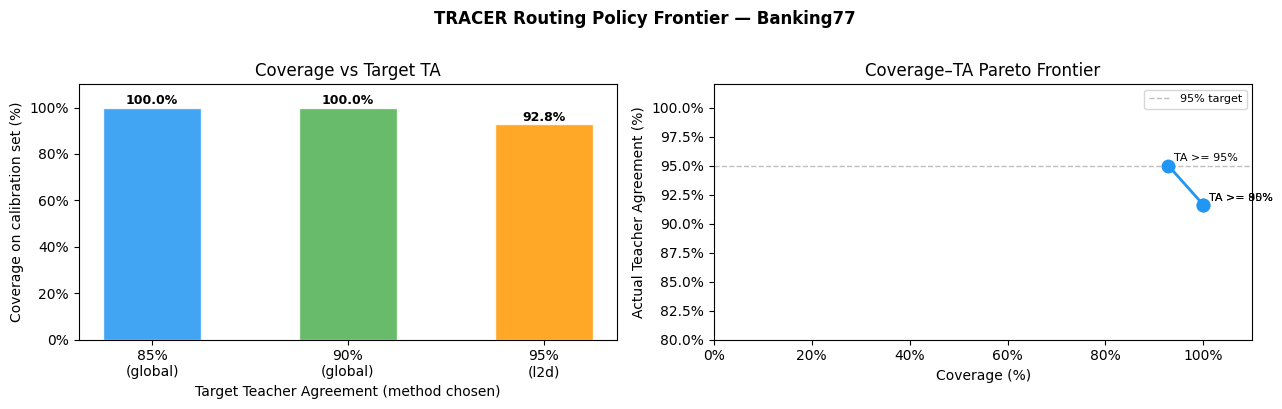

Saved → .tracer-banking77/frontier_plot.png


In [16]:
targets   = [item['target']        for item in frontier_raw]
coverages = [item['best_coverage'] or 0 for item in frontier_raw]
actual_ta = [item['best_ta']       or 0 for item in frontier_raw]
methods   = [item['best_method']   or 'none' for item in frontier_raw]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'][:len(targets)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ─── Left: Coverage at each target TA ────────────────────────────
ax = axes[0]
labels_x = [f'{t:.0%}\n({m})' for t, m in zip(targets, methods)]
bars = ax.bar(labels_x, [c * 100 for c in coverages], color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.set_xlabel('Target Teacher Agreement (method chosen)')
ax.set_ylabel('Coverage on calibration set (%)')
ax.set_title('Coverage vs Target TA')
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, cov in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{cov:.1%}', ha='center', fontsize=9, fontweight='bold')

# ─── Right: Coverage–TA Pareto frontier ──────────────────────────
ax = axes[1]
ax.plot([c * 100 for c in coverages], [t * 100 for t in actual_ta],
        'o-', color='#2196F3', linewidth=2, markersize=9, zorder=5)
for cov, ta, target in zip(coverages, actual_ta, targets):
    lbl = 'TA >= {:.0%}'.format(target)
    ax.annotate(lbl, xy=(cov * 100, ta * 100),
                xytext=(4, 3), textcoords='offset points', fontsize=8)
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='95% target')
ax.set_xlabel('Coverage (%)')
ax.set_ylabel('Actual Teacher Agreement (%)')
ax.set_title('Coverage–TA Pareto Frontier')
ax.set_ylim(80, 102)
ax.set_xlim(0, 110)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8)

plt.suptitle('TRACER Routing Policy Frontier - Banking77', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(ARTIFACT_DIR / 'frontier_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → .tracer-banking77/frontier_plot.png')

---
## 6. Explainability: The Qualitative Report

> *"We can't trust a routing policy we can't explain."*

TRACER builds a `QualitativeReport` automatically during `tracer.fit()`. It applies four distinct XAI lenses, each grounded in published literature:

| Lens | Technique | Reference |
|---|---|---|
| Slice-level summaries | Slice Finder | Chung et al., Google, 2019 |
| Representative examples | Influence Functions | Koh & Liang, ICML 2017 |
| Contrastive boundary pairs | Counterfactual Explanations | Wachter, Mittelstadt & Russell, 2017 |
| Temporal deltas | Dataset Cartography | Swayamdipta et al., EMNLP 2020 |

Together they answer: *Which intents get handled? What does a handled vs deferred query look like? How is the policy changing over time?*

In [17]:
qr = fit_result.qualitative_report

print('Qualitative report overview')
print('─' * 55)
print(f'  {qr.summary}')
print()
print(f'  Coverage:                {qr.coverage:.1%}')
print(f'  TA on handled slice:     {qr.teacher_agreement_handled:.4f}')
print()
print(f'  Slices computed:         {len(qr.slices)}')
print(f'    length bins:           {sum(1 for s in qr.slices if s.slice_name.startswith("length:"))}')
print(f'    label slices:          {sum(1 for s in qr.slices if s.slice_name.startswith("label:"))}')
print(f'  Representative examples: {len(qr.handled_examples)} handled, {len(qr.deferred_examples)} deferred')
print(f'  Boundary pairs:          {len(qr.boundary_pairs)}')
print(f'  Temporal deltas:         {len(qr.temporal_deltas)}')

Qualitative report overview
───────────────────────────────────────────────────────
  Handled 9608/10003 (96.1%) locally; deferred 395/10003 (3.9%).

  Coverage:                96.1%
  TA on handled slice:     0.9721

  Slices computed:         18
    length bins:           3
    label slices:          15
  Representative examples: 5 handled, 5 deferred
  Boundary pairs:          5
  Temporal deltas:         0


### 6.1 Slice-Level Summaries - *Slice Finder (Chung et al., Google 2019)*

Slices partition the data along interpretable axes to show **where the routing policy is confident vs uncertain**. TRACER computes two types:

1. **Length bins** (short / medium / long) - does the policy struggle with longer, more complex queries?
2. **Per-intent label slices** (top 15 by frequency) - which intents get routed locally vs escalated to the LLM?

Each slice reports: sample count, handled rate, deferred rate, teacher-agreement on handled examples.

In [18]:
length_slices = [s for s in qr.slices if s.slice_name.startswith('length:')]

print('── Length-bin slices ──────────────────────────────────────────────')
print(f'  {"Slice":<18}  {"Count":>7}  {"Handled":>9}  {"Deferred":>9}')
print('─' * 50)
for s in length_slices:
    print(f'  {s.slice_name:<18}  {s.count:>7,}  {s.handled_rate:>8.1%}  {s.deferred_rate:>8.1%}')

print()
print('Interpretation:')
if length_slices:
    short_h  = next((s.handled_rate for s in length_slices if 'short'  in s.slice_name), None)
    long_h   = next((s.handled_rate for s in length_slices if 'long'   in s.slice_name), None)
    if short_h and long_h:
        diff = short_h - long_h
        if diff > 0.05:
            print(f'  Short queries are handled {diff:.0%} more often than long ones.')
            print(f'  Longer, more ambiguous queries get deferred to the LLM more frequently.')
        else:
            print(f'  Handling rate is fairly consistent across input lengths ({diff:+.1%} diff).')

── Length-bin slices ──────────────────────────────────────────────
  Slice                 Count    Handled   Deferred
──────────────────────────────────────────────────
  length:short          3,464     96.3%      3.7%
  length:medium         3,225     96.6%      3.4%
  length:long           3,314     95.3%      4.7%

Interpretation:
  Handling rate is fairly consistent across input lengths (+1.0% diff).


── Label slices (top 15 intents by frequency) ──────────────────────
  Intent                                                    N    Handled    TA@handled
─────────────────────────────────────────────────────────────────────────────────────
  card_payment_fee_charged                                187     95.2%         0.927
  direct_debit_payment_not_recognised                     182     95.1%         0.948
  balance_not_updated_after_cheque_or_cash_deposit        181     94.5%         0.965
  wrong_amount_of_cash_received                           180     95.0%         0.994
  cash_withdrawal_charge                                  177     97.2%         0.988
  transaction_charged_twice                               175     97.7%         0.994
  declined_cash_withdrawal                                173     98.8%         0.977
  transfer_fee_charged                                    172     94.2%         0.901
  transfer_not_received_by_recipient                      171     87.7

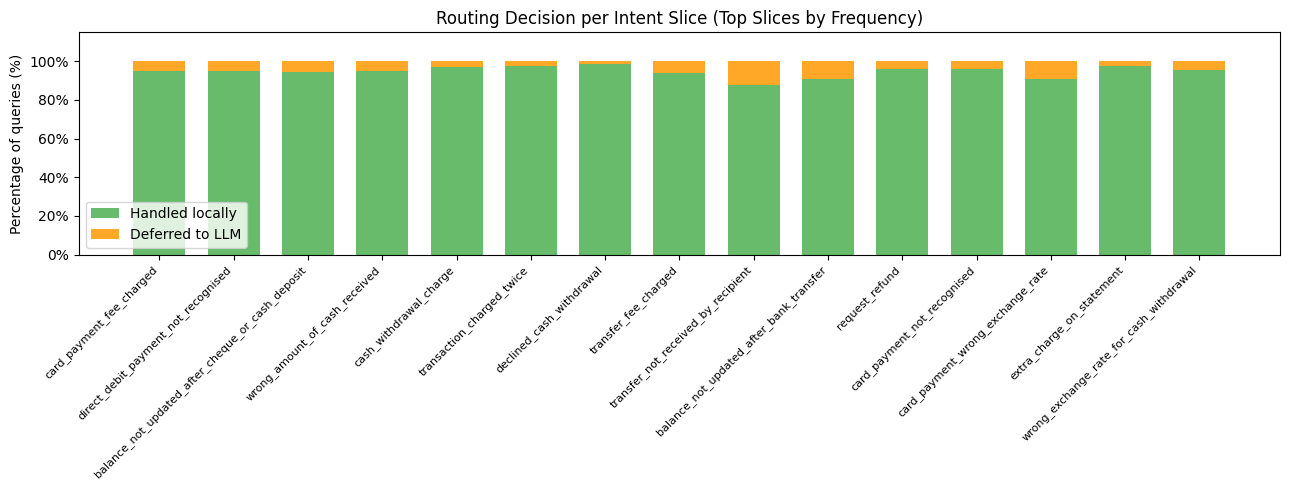

In [19]:
label_slices = [s for s in qr.slices if s.slice_name.startswith('label:')]

print(f'── Label slices (top {len(label_slices)} intents by frequency) ──────────────────────')
print(f'  {"Intent":<52}  {"N":>5}  {"Handled":>9}  {"TA@handled":>12}')
print('─' * 85)
for s in label_slices:
    lbl = s.slice_name.replace('label:', '')
    ta  = f'{s.teacher_agreement_handled:.3f}' if s.teacher_agreement_handled is not None else 'N/A'
    print(f'  {lbl:<52}  {s.count:>5,}  {s.handled_rate:>8.1%}  {ta:>12}')

# ── Visualization ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

names    = [s.slice_name.replace('label:', '') for s in label_slices]
handled  = [s.handled_rate * 100 for s in label_slices]
deferred = [s.deferred_rate * 100 for s in label_slices]
x = np.arange(len(names))

ax.bar(x, handled,  0.7, label='Handled locally', color='#4CAF50', alpha=0.85)
ax.bar(x, deferred, 0.7, bottom=handled, label='Deferred to LLM', color='#FF9800', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Percentage of queries (%)')
ax.set_title('Routing Decision per Intent Slice (Top Slices by Frequency)')
ax.legend()
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

### 6.2 Representative Examples - *Influence Functions (Koh & Liang, ICML 2017)*

For each routing bucket (handled / deferred), TRACER surfaces the **most typical queries**: those nearest the median input length. This is inspired by influence-function analysis - the median examples best represent the mode of the distribution, not the outliers.

Each card shows:
- The query text
- The teacher's label (what the LLM said)
- The surrogate's label (if handled)
- The **accept score**: the acceptor's estimated probability of teacher-agreement

In [20]:
print(f'── Handled examples (surrogate is confident it matches the teacher) ──')
print()
for i, ex in enumerate(qr.handled_examples):
    score_str = f'  accept_score: {ex.accept_score:.3f}' if ex.accept_score is not None else ''
    match = '✓' if ex.local_label == ex.teacher_label else '✗'
    print(f'  [{i+1}] {match} Teacher: {ex.teacher_label}')
    print(f'      Surrogate: {ex.local_label}')
    print(f'      {score_str.strip()}')
    print(f'      Query: "{ex.input_preview[:110]}"')
    print()

── Handled examples (surrogate is confident it matches the teacher) ──

  [1] ✓ Teacher: card_arrival
      Surrogate: card_arrival
      accept_score: 0.941
      Query: "What is the expected delivery date for my card?"

  [2] ✓ Teacher: card_linking
      Surrogate: card_linking
      accept_score: 0.972
      Query: "I just got a card, how can I add it to the app?"

  [3] ✓ Teacher: card_linking
      Surrogate: card_linking
      accept_score: 0.968
      Query: "If my card was lost or stolen can I re-link it?"

  [4] ✓ Teacher: card_linking
      Surrogate: card_linking
      accept_score: 0.972
      Query: "if i found a lost card can i put it back in app"

  [5] ✓ Teacher: exchange_rate
      Surrogate: exchange_rate
      accept_score: 0.971
      Query: "How are exchange rates calculated at this bank?"



In [21]:
print(f'── Deferred examples (surrogate not confident - escalated to LLM) ──')
print()
for i, ex in enumerate(qr.deferred_examples):
    score_str = f'  accept_score: {ex.accept_score:.3f}' if ex.accept_score is not None else ''
    print(f'  [{i+1}] Teacher: {ex.teacher_label}')
    print(f'      {score_str.strip()}')
    print(f'      Query: "{ex.input_preview[:110]}"')
    print()

── Deferred examples (surrogate not confident - escalated to LLM) ──

  [1] Teacher: card_not_working
      accept_score: 0.000
      Query: "Can you tell me why I can't make any transactions?"

  [2] Teacher: transfer_not_received_by_recipient
      accept_score: 0.000
      Query: "Why isn't the transfer I made to a friend showing?"

  [3] Teacher: disposable_card_limits
      accept_score: 0.000
      Query: "How many payments can I make using a virtual card?"

  [4] Teacher: declined_card_payment
      accept_score: 0.000
      Query: "is there a reason that my payment didnt go through"

  [5] Teacher: apple_pay_or_google_pay
      accept_score: 0.000
      Query: "top up for my american express card is not working"



### 6.3 Contrastive Boundary Pairs - *Counterfactual Explanations (Wachter, Mittelstadt & Russell, 2017)*

For each intent label, TRACER finds **two queries with the same teacher label but opposite routing outcomes**: one was handled locally (high accept score), one was deferred (low accept score).

This directly answers: *"For intent X, what makes a query easy to route locally vs uncertain?"* - the kind of contrastive explanation that helps a product team understand and trust the policy.

The accept score gap shows how far apart the two queries are in the decision space.

In [22]:
print(f'── Contrastive boundary pairs ({len(qr.boundary_pairs)} pairs) ──────────────────────────')
for i, bp in enumerate(qr.boundary_pairs):
    score_h = f'score={bp.handled_score:.3f}' if bp.handled_score is not None else ''
    score_d = f'score={bp.deferred_score:.3f}' if bp.deferred_score is not None else ''
    if bp.handled_score is not None and bp.deferred_score is not None:
        gap = bp.handled_score - bp.deferred_score
        gap_str = f'  gap = {gap:+.3f}'
    else:
        gap_str = ''
    print(f'\n  Pair {i+1}  label = {repr(bp.teacher_label)}{gap_str}')
    print(f'  HANDLED   ({score_h}):')
    print(f'    "{bp.handled_preview[:115]}"')
    print(f'  DEFERRED  ({score_d}):')
    print(f'    "{bp.deferred_preview[:115]}"')

── Contrastive boundary pairs (5 pairs) ──────────────────────────

  Pair 1  label = 'Refund_not_showing_up'  gap = +0.971
  HANDLED   (score=0.971):
    "Card refund is not showing up in my statement."
  DEFERRED  (score=0.000):
    "who should i contact if my refund doesn't go through?"

  Pair 2  label = 'activate_my_card'  gap = +0.972
  HANDLED   (score=0.972):
    "I would like to activate my card what do I need to do?"
  DEFERRED  (score=0.000):
    "How can I switch on my new card?"

  Pair 3  label = 'apple_pay_or_google_pay'  gap = +0.971
  HANDLED   (score=0.971):
    "Unable to use my American Express with Apple Pay to top up my account"
  DEFERRED  (score=0.000):
    "top up for my american express card is not working"

  Pair 4  label = 'atm_support'  gap = +0.972
  HANDLED   (score=0.972):
    "Is the closest ATM to me within 2 miles?"
  DEFERRED  (score=0.000):
    "Can I use my card to withdraw from my account?"

  Pair 5  label = 'automatic_top_up'  gap = +0.961
  HA

### 6.4 Temporal Deltas - *Dataset Cartography (Swayamdipta et al., EMNLP 2020)*

Temporal deltas track **how the handled rate for each intent changes across retrains**. Inspired by Dataset Cartography's notion of training dynamics, they reveal which intents are becoming easier or harder to route locally over time - the "routing trajectory" of the system.

**This is the lens that powers continual learning:** if `card_arrival` goes from 62% → 81% handled, the system is getting better at routing that intent locally. If `transfer_timing` goes 45% → 31%, something changed - new query patterns, concept drift, or data shift.

In this static notebook we only have one fit, so deltas are empty. Run `tracer.update()` with new traces to populate this section.

In [23]:
if qr.temporal_deltas:
    print(f'Temporal deltas (top {len(qr.temporal_deltas)} intents by change magnitude):')
    print('─' * 65)
    for td in qr.temporal_deltas:
        arrow = '↑' if td.delta > 0 else '↓'
        print(f'  {arrow}  {td.label:<50}  '
              f'{td.previous_handled_rate:.0%} → {td.current_handled_rate:.0%}  '
              f'({td.delta:+.0%})')
else:
    print('No temporal deltas - only one fit so far.')
    print()
    print('After calling tracer.update() with new traces, deltas will appear here:')
    print()
    print('  Example output after a second fit:')
    print('  ↑  card_arrival                              62% → 81%  (+19%)')
    print('  ↑  balance_not_updated_after_bank_transfer   45% → 67%  (+22%)')
    print('  ↓  transfer_timing                           55% → 31%  (-24%)  ← investigate!')
    print()
    print('See 03-dynamic-tracer.ipynb for the full continual-learning demo.')

No temporal deltas - only one fit so far.

After calling tracer.update() with new traces, deltas will appear here:

  Example output after a second fit:
  ↑  card_arrival                              62% → 81%  (+19%)
  ↑  balance_not_updated_after_bank_transfer   45% → 67%  (+22%)
  ↓  transfer_timing                           55% → 31%  (-24%)  ← investigate!

See 03-dynamic-tracer.ipynb for the full continual-learning demo.


---
## 7. Test Set Evaluation

Now we evaluate the fitted policy on the **held-out test set** (3,080 queries). This is the honest evaluation - the policy was never trained on these examples.

`evaluate_pipeline()` runs the full cascade and computes:

| Metric | Definition |
|---|---|
| `coverage` | Fraction of test queries handled locally |
| `teacher_agreement_handled` | % of handled queries where surrogate matches teacher |
| `gt_f1_handled` | Macro-F1 on the handled slice vs ground truth |
| `e2e_gt_f1` | End-to-end macro-F1 (surrogate for handled, teacher for deferred) |
| `e2e_gt_acc` | End-to-end accuracy |

> In Banking77, `teacher == ground_truth` (the dataset labels are the teacher signal). So `teacher_agreement_handled == gt_acc_handled` and `e2e_teacher_agreement == e2e_gt_acc`.

In [24]:
from tracer.policy.artifacts import load_pipeline
from tracer.fit.pipeline import evaluate_pipeline

# ── Load the fitted pipeline ──────────────────────────────────────
bundle      = load_pipeline(ARTIFACT_DIR)
pipeline    = bundle['pipeline']
label_space = bundle['label_space']
label_to_idx = {lbl: i for i, lbl in enumerate(label_space)}

# ── Load test embeddings ──────────────────────────────────────────
X_test = np.load(DATA_DIR / 'banking77_test_embeddings.npy').astype(np.float32)

tl_path = DATA_DIR / 'banking77_test_embeddings_too_long.npy'
too_long_test = np.load(tl_path) if tl_path.exists() else np.zeros(len(test_df), dtype=bool)

# ── Align (drop rows flagged as too-long) ────────────────────────
valid_mask    = ~too_long_test
test_df_valid = test_df[valid_mask].reset_index(drop=True)
X_test_valid  = X_test[valid_mask]

print(f'Test set: {len(X_test_valid):,} valid samples '
      f'(dropped {int(too_long_test.sum())} too-long)')

# ── Encode labels ─────────────────────────────────────────────────
# Some test intents might not appear in train label_space - map to 0 as fallback
y_test = np.array(
    [label_to_idx.get(lbl, 0) for lbl in test_df_valid['intent'].tolist()]
)
n_unknown = sum(1 for lbl in test_df_valid['intent'].tolist() if lbl not in label_to_idx)
if n_unknown:
    print(f'Warning: {n_unknown} test labels not in train label space (mapped to fallback)')

# ── Evaluate ──────────────────────────────────────────────────────
# Since teacher == ground_truth in Banking77, pass y_test as both arguments.
print(f'\nRunning evaluate_pipeline on {len(X_test_valid):,} test embeddings...')
metrics = evaluate_pipeline(pipeline, X_test_valid, y_test, y_test)

Test set: 3,080 valid samples (dropped 0 too-long)

Running evaluate_pipeline on 3,080 test embeddings...


In [25]:
n_total   = len(X_test_valid)
n_handled = int(metrics['coverage'] * n_total)
n_deferred = metrics['n_deferred']

print('=' * 60)
print('Test set evaluation')
print('=' * 60)
print()
print('  ── Routing ──────────────────────────────────────────')
print(f'  Coverage (handled locally):    {metrics["coverage"]:>8.1%}  ({n_handled:,} / {n_total:,})')
print(f'  Deferred to LLM:               {1-metrics["coverage"]:>8.1%}  ({n_deferred:,} / {n_total:,})')
print()
print('  ── Quality on handled slice ─────────────────────────')
print(f'  Teacher agreement:             {metrics["teacher_agreement_handled"]:>8.3f}')
print(f'  Accuracy:                      {metrics["gt_acc_handled"]:>8.3f}')
print(f'  Macro-F1:                      {metrics["gt_f1_handled"]:>8.3f}')
print()
print('  ── End-to-end (surrogate + LLM combined) ────────────')
print(f'  Accuracy:                      {metrics["e2e_gt_acc"]:>8.3f}')
print(f'  Macro-F1:                      {metrics["e2e_gt_f1"]:>8.3f}')
print(f'  Teacher agreement:             {metrics["e2e_teacher_agreement"]:>8.3f}')
print()

# Stage breakdown
stage_ids = metrics['stage_id']
handled   = metrics['handled']
if handled.any():
    stage_counts = Counter(stage_ids[handled].tolist())
    print('  ── Stage breakdown ──────────────────────────────────')
    for s, count in sorted(stage_counts.items()):
        pct = count / n_total
        print(f'  Stage {s+1}:                        {count:>5,} queries  ({pct:.1%})')

Test set evaluation

  ── Routing ──────────────────────────────────────────
  Coverage (handled locally):       92.2%  (2,841 / 3,080)
  Deferred to LLM:                   7.8%  (239 / 3,080)

  ── Quality on handled slice ─────────────────────────
  Teacher agreement:                0.961
  Accuracy:                         0.961
  Macro-F1:                         0.959

  ── End-to-end (surrogate + LLM combined) ────────────
  Accuracy:                         0.964
  Macro-F1:                         0.964
  Teacher agreement:                0.964

  ── Stage breakdown ──────────────────────────────────
  Stage 1:                        2,841 queries  (92.2%)


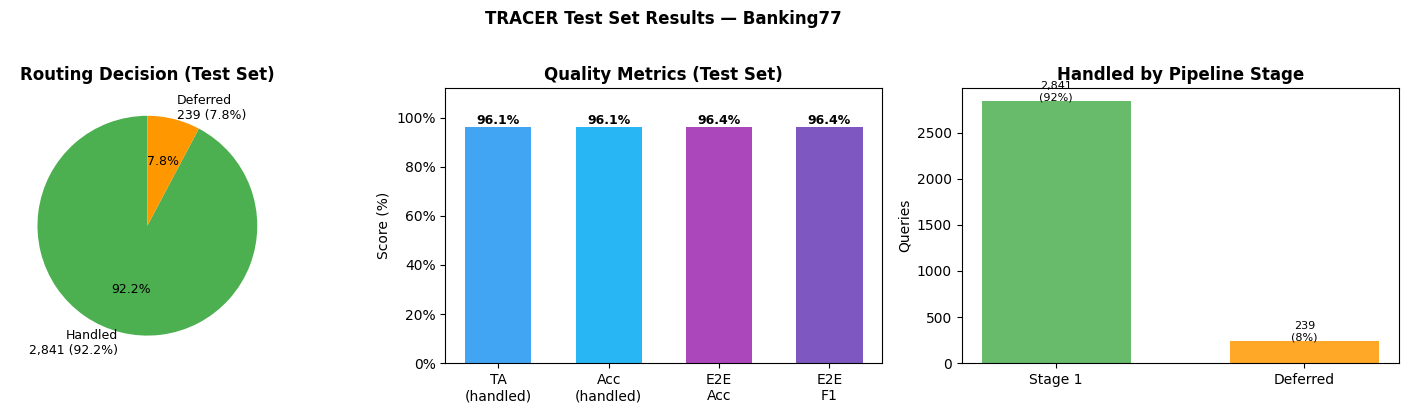

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ─── 1. Routing pie ──────────────────────────────────────────────
ax = axes[0]
pie_labels = [
    f'Handled\n{n_handled:,} ({metrics["coverage"]:.1%})',
    f'Deferred\n{n_deferred:,} ({1-metrics["coverage"]:.1%})',
]
ax.pie([n_handled, n_deferred], labels=pie_labels,
       colors=['#4CAF50', '#FF9800'], autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 9})
ax.set_title('Routing Decision (Test Set)', fontweight='bold')

# ─── 2. Key metrics bar ──────────────────────────────────────────
ax = axes[1]
bar_names = ['TA\n(handled)', 'Acc\n(handled)', 'E2E\nAcc', 'E2E\nF1']
bar_vals  = [
    metrics['teacher_agreement_handled'],
    metrics['gt_acc_handled'],
    metrics['e2e_gt_acc'],
    metrics['e2e_gt_f1'],
]
bar_colors = ['#2196F3', '#03A9F4', '#9C27B0', '#673AB7']
bars = ax.bar(bar_names, [v * 100 for v in bar_vals],
              color=bar_colors, alpha=0.85, width=0.6)
ax.set_ylim(0, 112)
ax.set_ylabel('Score (%)')
ax.set_title('Quality Metrics (Test Set)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

# ─── 3. Stage distribution ───────────────────────────────────────
ax = axes[2]
if handled.any():
    stage_counts = Counter(stage_ids[handled].tolist())
    stage_labels = [f'Stage {s+1}' for s in sorted(stage_counts.keys())]
    stage_cnts   = [stage_counts[s] for s in sorted(stage_counts.keys())]
    deferred_cnt = [n_deferred]
    all_labels = stage_labels + ['Deferred']
    all_cnts   = stage_cnts   + deferred_cnt
    all_colors = ['#4CAF50', '#8BC34A'][:len(stage_labels)] + ['#FF9800']
    bars2 = ax.bar(all_labels, all_cnts, color=all_colors[:len(all_labels)], alpha=0.85, width=0.6)
    ax.set_ylabel('Queries')
    ax.set_title('Handled by Pipeline Stage', fontweight='bold')
    for bar, cnt in zip(bars2, all_cnts):
        pct = cnt / n_total
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f'{cnt:,}\n({pct:.0%})', ha='center', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No handled samples', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Handled by Stage')

plt.suptitle('TRACER Test Set Results - Banking77', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. The Production Router

`tracer.load_router()` returns a `Router` object ready for live traffic. In production you:

1. Embed the incoming query (same model used at training time)
2. Call `router.predict(embedding)` - returns label, decision, accept score, stage
3. If `decision == 'deferred'`, call your LLM fallback

The router is **stateless** - it just runs the fitted classifiers and applies the calibrated threshold.

In [27]:
router = tracer.load_router(ARTIFACT_DIR)

print(f'Router loaded from {ARTIFACT_DIR}')
print(f'  Method:         {router.manifest.selected_method}')
print(f'  Label space:    {len(router.manifest.label_space)} intents')
print(f'  Trained on:     {router.manifest.n_traces:,} traces')
print(f'  Embedding dim:  {router.manifest.embedding_dim}')
print()
cov_str = f'{router.manifest.coverage_cal:.1%}' if router.manifest.coverage_cal is not None else 'N/A'
ta_str  = f'{router.manifest.teacher_agreement_cal:.4f}' if router.manifest.teacher_agreement_cal is not None else 'N/A'
print(f'  Coverage (cal): {cov_str}')
print(f'  TA (cal):       {ta_str}')

Router loaded from .tracer-banking77
  Method:         l2d
  Label space:    77 intents
  Trained on:     10,003 traces
  Embedding dim:  1024

  Coverage (cal): 92.8%
  TA (cal):       0.9500


In [28]:
# Route a handful of individual test queries
example_indices = [0, 10, 50, 100, 250, 500]

print('── Single-query routing demo ──────────────────────────────────────')
print()
for idx in example_indices:
    if idx >= len(X_test_valid):
        continue
    emb         = X_test_valid[idx]
    true_intent = test_df_valid.iloc[idx]['intent']
    query_text  = test_df_valid.iloc[idx]['text']

    result = router.predict(emb)

    decision = result['decision']
    label    = result['label'] or '(deferred to LLM)'
    score    = result['accept_score']
    stage    = result['stage']

    if result['decision'] == 'handled':
        correct = '✓' if result['label'] == true_intent else '✗'
        dec_icon = 'HANDLED  '
    else:
        correct = '-'
        dec_icon = 'DEFERRED '

    print(f'  [{correct}] {dec_icon}  score={score:.3f}  stage={stage}')
    print(f'      Query:     "{query_text[:72]}"')
    print(f'      True:      {true_intent}')
    print(f'      Predicted: {label}')
    print()

── Single-query routing demo ──────────────────────────────────────

  [✗] HANDLED    score=0.825  stage=0
      Query:     "How do I locate my card?"
      True:      card_arrival
      Predicted: lost_or_stolen_card

  [✓] HANDLED    score=0.969  stage=0
      Query:     "How do I track my card?"
      True:      card_arrival
      Predicted: card_arrival

  [✓] HANDLED    score=0.971  stage=0
      Query:     "How do I link a new card?"
      True:      card_linking
      Predicted: card_linking

  [✓] HANDLED    score=0.972  stage=0
      Query:     "What is the base of the exchange rates?"
      True:      exchange_rate
      Predicted: exchange_rate

  [✓] HANDLED    score=0.958  stage=0
      Query:     "Where can I exchange my money for EUR?"
      True:      fiat_currency_support
      Predicted: fiat_currency_support

  [✓] HANDLED    score=0.971  stage=0
      Query:     "Can my 19 year old daughter open a savings account at the bank?"
      True:      age_limit
      Predic

In [29]:
# Batch routing - more efficient for bulk inference
N_BATCH = 200

batch_result = router.predict_batch(X_test_valid[:N_BATCH])

decisions = batch_result['decisions']
labels    = batch_result['labels']
handled   = np.array(batch_result['handled'])
preds     = np.array(batch_result['preds'])
y_batch   = y_test[:N_BATCH]

n_handled_b  = handled.sum()
n_deferred_b = N_BATCH - n_handled_b

if handled.any():
    acc_handled = (preds[handled] == y_batch[handled]).mean()
else:
    acc_handled = 0.0

print(f'Batch routing results ({N_BATCH} queries):')
print(f'  Handled locally:     {n_handled_b:>4} ({n_handled_b/N_BATCH:.0%})')
print(f'  Deferred to LLM:     {n_deferred_b:>4} ({n_deferred_b/N_BATCH:.0%})')
print(f'  Accuracy on handled: {acc_handled:.1%}')
print()
print('  First 10 routing decisions:')
print(f'  {"Decision":>10}  {"Query (truncated)":<55}  {"Label"}')
print('  ' + '─' * 85)
for i in range(min(10, N_BATCH)):
    q   = test_df_valid.iloc[i]['text'][:53]
    dec = decisions[i]
    lbl = labels[i] or '(deferred)'
    ico = '✓' if dec == 'handled' else '→'
    print(f'  {ico} {dec:>9}  {q:<55}  {lbl}')

Batch routing results (200 queries):
  Handled locally:      186 (93%)
  Deferred to LLM:       14 (7%)
  Accuracy on handled: 95.7%

  First 10 routing decisions:
    Decision  Query (truncated)                                        Label
  ─────────────────────────────────────────────────────────────────────────────────────
  ✓   handled  How do I locate my card?                                 lost_or_stolen_card
  ✓   handled  I still have not received my new card, I ordered over    card_arrival
  ✓   handled  I ordered a card but it has not arrived. Help please!    card_arrival
  ✓   handled  Is there a way to know when my card will arrive?         card_arrival
  ✓   handled  My card has not arrived yet.                             card_arrival
  →  deferred  When will I get my card?                                 (deferred)
  ✓   handled  Do you know if there is a tracking number for the new    card_arrival
  ✓   handled  i have not received my card                             

---
## 9. Cost Analysis

The central value of TRACER is **LLM cost reduction** without sacrificing quality. Each query handled locally saves one LLM API call.

For Banking77, queries are very short (~15 tokens on average), so the per-call cost is low - but at production scale (thousands to millions of queries per day), routing savings compound quickly.

Edit the parameters below to match your LLM and traffic pattern.

In [30]:
# ── Parameters - adjust to your deployment ────────────────────────
queries_per_day    = 10_000
avg_input_tokens   = max(1, int(train_df['text_len'].mean() / 4))  # ~15
avg_output_tokens  = 5                # just the intent label token
cost_per_1m_input  = 3.00             # USD / 1M input tokens (e.g. GPT-4o-mini)
cost_per_1m_output = 15.00            # USD / 1M output tokens
# ──────────────────────────────────────────────────────────────────

coverage = metrics['coverage']

cost_per_query_usd = (
    avg_input_tokens  * cost_per_1m_input  / 1_000_000 +
    avg_output_tokens * cost_per_1m_output / 1_000_000
)

annual_cost_without = queries_per_day * 365 * cost_per_query_usd
annual_cost_with    = annual_cost_without * (1 - coverage)
annual_savings      = annual_cost_without - annual_cost_with

print('── Input parameters ─────────────────────────────────────────────────')
print(f'  Queries per day:      {queries_per_day:,}')
print(f'  Avg tokens per query: {avg_input_tokens} input + {avg_output_tokens} output')
print(f'  LLM pricing:          ${cost_per_1m_input:.2f} / 1M input, ${cost_per_1m_output:.2f} / 1M output')
print(f'  Cost per call:        ${cost_per_query_usd * 1000:.4f} per 1,000 calls')
print()
print('── Cost comparison ──────────────────────────────────────────────────')
print(f'  WITHOUT TRACER (100% LLM):')
print(f'    Daily:   ${queries_per_day * cost_per_query_usd:>10.2f}')
print(f'    Annual:  ${annual_cost_without:>10,.0f}')
print()
print(f'  WITH TRACER (coverage = {coverage:.1%}):')
print(f'    Daily:   ${queries_per_day * (1 - coverage) * cost_per_query_usd:>10.2f}')
print(f'    Annual:  ${annual_cost_with:>10,.0f}')
print()
print(f'  ── SAVINGS ────────────────────────────────────────────────────────')
print(f'     Annual savings: ${annual_savings:>10,.0f}  ({coverage:.1%} reduction in LLM calls)')
print()
print('── Quality preserved ────────────────────────────────────────────────')
print(f'  Teacher agreement on handled:  {metrics["teacher_agreement_handled"]:.1%}')
print(f'  End-to-end accuracy:           {metrics["e2e_gt_acc"]:.1%}  (vs 100% if all-LLM)')
print(f'  End-to-end macro-F1:           {metrics["e2e_gt_f1"]:.3f}')

── Input parameters ─────────────────────────────────────────────────
  Queries per day:      10,000
  Avg tokens per query: 14 input + 5 output
  LLM pricing:          $3.00 / 1M input, $15.00 / 1M output
  Cost per call:        $0.1170 per 1,000 calls

── Cost comparison ──────────────────────────────────────────────────
  WITHOUT TRACER (100% LLM):
    Daily:   $      1.17
    Annual:  $       427

  WITH TRACER (coverage = 92.2%):
    Daily:   $      0.09
    Annual:  $        33

  ── SAVINGS ────────────────────────────────────────────────────────
     Annual savings: $       394  (92.2% reduction in LLM calls)

── Quality preserved ────────────────────────────────────────────────
  Teacher agreement on handled:  96.1%
  End-to-end accuracy:           96.4%  (vs 100% if all-LLM)
  End-to-end macro-F1:           0.964


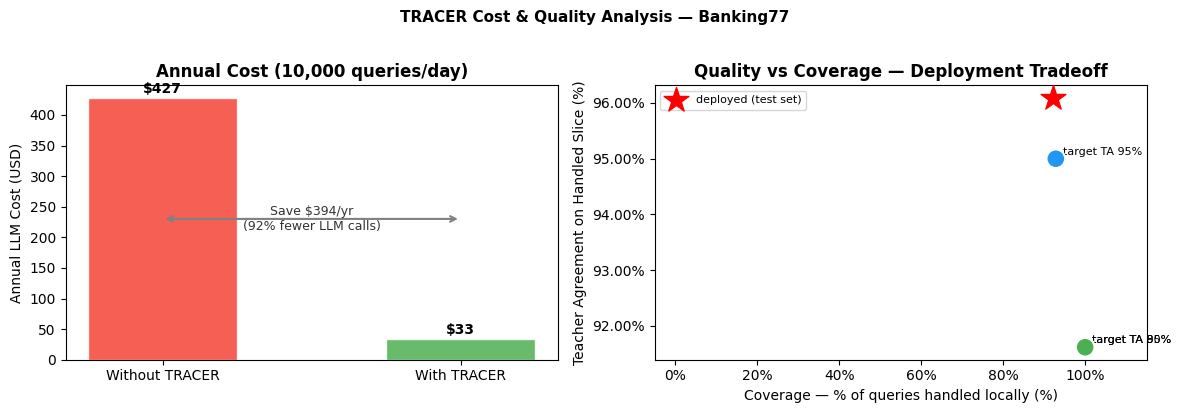

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ─── Left: Annual cost comparison ────────────────────────────────
ax = axes[0]
categories = ['Without TRACER', 'With TRACER']
costs      = [annual_cost_without, annual_cost_with]
clrs       = ['#f44336', '#4CAF50']
bars = ax.bar(categories, costs, color=clrs, alpha=0.85, width=0.5, edgecolor='white')
ax.set_ylabel('Annual LLM Cost (USD)')
ax.set_title(f'Annual Cost ({queries_per_day:,} queries/day)', fontweight='bold')
for bar, val in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + annual_cost_without * 0.02,
            f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
savings_label = f'Save ${annual_savings:,.0f}/yr\n({coverage:.0%} fewer LLM calls)'
ax.annotate('', xy=(1, annual_cost_with + (annual_savings * 0.5)),
            xytext=(0, annual_cost_without - (annual_savings * 0.5)),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(0.5, (annual_cost_without + annual_cost_with) / 2,
        savings_label, ha='center', fontsize=9, color='#333', va='center')

# ─── Right: Quality vs coverage tradeoff at all frontier points ──
ax = axes[1]
f_covs = [item['best_coverage'] or 0 for item in frontier_raw]
f_tas  = [item['best_ta']       or 0 for item in frontier_raw]

ax.scatter([c * 100 for c in f_covs], [t * 100 for t in f_tas],
           c=['#FF9800', '#4CAF50', '#2196F3'][:len(f_covs)],
           s=180, zorder=5, edgecolors='white', linewidths=1.5)
for cov, ta, item in zip(f_covs, f_tas, frontier_raw):
    lbl = 'target TA {:.0%}'.format(item['target'])
    ax.annotate(lbl, xy=(cov * 100, ta * 100),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

# Mark deployed point
ax.scatter([metrics['coverage'] * 100], [metrics['teacher_agreement_handled'] * 100],
           marker='*', s=350, c='red', zorder=6, label='deployed (test set)')

ax.set_xlabel('Coverage - % of queries handled locally (%)')
ax.set_ylabel('Teacher Agreement on Handled Slice (%)')
ax.set_title('Quality vs Coverage - Deployment Tradeoff', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(-5, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('TRACER Cost & Quality Analysis - Banking77', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Summary & What's Next

You've just built a complete TRACER routing policy on Banking77. Here's what happened end-to-end:

| Step | Action | Result |
|---|---|---|
| 1 | Loaded Banking77 | 10,003 train + 3,080 test queries, 77 intents |
| 2 | Formatted as LLM traces | JSONL with `input`, `teacher`, `id`, `ground_truth` |
| 3 | Loaded BGE-M3 embeddings | 1024-dim precomputed vectors from HuggingFace |
| 4 | Fitted TRACER | global / L2D / RSB candidates; best selected at target TA |
| 5 | Inspected artifacts | Manifest, frontier, config all serialized to `.tracer-banking77/` |
| 6 | Examined XAI report | Slices · Examples · Boundary pairs · Temporal deltas |
| 7 | Evaluated on test set | Honest hold-out: coverage, TA, F1, end-to-end accuracy |
| 8 | Loaded production router | Single and batch prediction with per-query accept scores |
| 9 | Quantified cost savings | LLM call reduction at maintained quality |

### Key principles

- **Parity guarantee**: the conformal threshold ensures ≥ (1 − ε) of accepted samples match the teacher on calibration data - distribution-free, finite-sample
- **Explainability**: the qualitative report gives every routing decision an audit trail, grounded in published XAI literature
- **Model-agnostic**: swap BGE-M3 for any other embedder; swap the teacher label source for any LLM
- **Continual learning**: `tracer.update()` appends new traces and refits - the safe handled region grows as more data arrives

### What's next

| Notebook | Description |
|---|---|
| `03-dynamic-tracer.ipynb` | Simulate traces arriving over time; run `tracer.update()` repeatedly; observe coverage growth and temporal deltas in action |

```python
# Continual learning preview
updated = tracer.update(
    'data/new_traces.jsonl',
    artifact_dir='.tracer-banking77',
)
print(updated.qualitative_report.temporal_deltas)
```